# MFCC Audio Classification — Arduino Pipeline
## Audio → MFCC → CNN → TFLite INT8 → `model.h`

**Classi:** `clap` · `tap` · `snap` · `silence`

> ⚠️ *"MFCC on-device must match MFCC on Colab — otherwise no accurate classification!"*
>
> I parametri della Sezione 1 devono essere **identici** ai `#define` dello sketch Arduino.

## 0 — Dipendenze

In [ ]:
!pip install -q librosa soundfile tensorflow numpy matplotlib scikit-learn seaborn pydub
!apt-get install -q ffmpeg

Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


## 1 — Parametri MFCC

```cpp
#define SAMPLE_RATE   16000
#define FRAME_LEN     256      // 16 ms (slide CMSIS)
#define HOP_LEN       128      // 8 ms, 50% overlap
#define N_MEL         26       // filtri Mel
#define N_MFCC        13       // coefficienti cepstrali
#define MEL_LOW_HZ    300.0f
#define MEL_HIGH_HZ   8000.0f
#define PRE_EMPHASIS  0.97f
```

In [ ]:
import numpy as np
import os

# ── Audio ─────────────────────────────────────────────────────────────────────
SAMPLE_RATE   = 16000
CLIP_DURATION = 1.0
N_SAMPLES     = int(SAMPLE_RATE * CLIP_DURATION)   # 16000

# ── MFCC — identici ai #define dello sketch Arduino (CMSIS-DSP) ──────────────
FRAME_LEN     = 256
HOP_LEN       = 128
N_MEL         = 26
N_MFCC        = 13
MEL_LOW_HZ    = 300.0
MEL_HIGH_HZ   = 8000.0
PRE_EMPHASIS  = 0.97

# ── Classi ────────────────────────────────────────────────────────────────────
CLASSES   = ['clap', 'tap', 'snap', 'silence']
N_CLASSES = len(CLASSES)

# ── Training ──────────────────────────────────────────────────────────────────
TARGET_PER_CLASS = 250
EPOCHS           = 60
BATCH_SIZE       = 16
VAL_SPLIT        = 0.2
SEED             = 42

# NUM_FRAMES: identico allo sketch  →  (16000 - 256) // 128 + 1 = 124
NUM_FRAMES = (N_SAMPLES - FRAME_LEN) // HOP_LEN + 1
N_FFT_BINS = FRAME_LEN // 2 + 1   # 129
print(f'Config OK — MFCC input shape: (1, {N_MFCC}, {NUM_FRAMES}, 1)')
assert NUM_FRAMES == 124, f'Atteso 124, ottenuto {NUM_FRAMES}'


Config OK — MFCC input shape: (1, 13, 124, 1)


## 2 — Caricamento dataset

Carica uno ZIP con questa struttura (i file possono essere `.wav` **o** `.mp4`):
```
dataset.zip
├── clap/    → almeno 1 file audio
├── tap/     → almeno 1 file audio
├── snap/    → almeno 1 file audio
└── silence/ → almeno 1 file audio (oppure verrà generato sinteticamente)
```

In [ ]:
import zipfile
from google.colab import files

uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('dataset')

# Trova il root che contiene le cartelle delle classi
DATA_ROOT = 'dataset'
for root, dirs, _ in os.walk('dataset'):
    if any(c in dirs for c in CLASSES):
        DATA_ROOT = root
        break

print(f'Dataset root: {DATA_ROOT}')
for cls in CLASSES:
    p = os.path.join(DATA_ROOT, cls)
    os.makedirs(p, exist_ok=True)
    files_all = os.listdir(p) if os.path.exists(p) else []
    n_wav = len([f for f in files_all if f.lower().endswith('.wav')])
    n_mp4 = len([f for f in files_all if f.lower().endswith('.mp4')])
    print(f'  {cls}: {n_wav} wav, {n_mp4} mp4')

Saving dataset_fixed.zip to dataset_fixed.zip
Dataset root: dataset
  clap: 10 wav, 0 mp4
  tap: 10 wav, 0 mp4
  snap: 10 wav, 0 mp4
  silence: 10 wav, 0 mp4


## 3 — Conversione MP4 → WAV

Converte automaticamente tutti i file `.mp4` in `.wav` mono 16 kHz.

In [ ]:
from pydub import AudioSegment

for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    mp4_files = [f for f in os.listdir(cls_dir) if f.lower().endswith('.mp4')]
    for mp4 in mp4_files:
        src = os.path.join(cls_dir, mp4)
        dst = os.path.join(cls_dir, os.path.splitext(mp4)[0] + '.wav')
        audio = AudioSegment.from_file(src, format='mp4')
        audio = audio.set_channels(1).set_frame_rate(SAMPLE_RATE)
        audio.export(dst, format='wav')
    if mp4_files:
        print(f'  {cls}: {len(mp4_files)} mp4 convertiti ✅')

# Report finale
print('\nFile .wav disponibili dopo conversione:')
for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    n = len([f for f in os.listdir(cls_dir)
             if f.lower().endswith('.wav') and 'synth' not in f and 'aug' not in f])
    print(f'  {cls}: {n} file originali')


File .wav disponibili dopo conversione:
  clap: 10 file originali
  tap: 10 file originali
  snap: 10 file originali
  silence: 10 file originali


## 4 — Data Augmentation

Da pochi campioni originali genera `TARGET_PER_CLASS` campioni per classe applicando:
- Rumore di fondo
- Time stretch (±15%)
- Pitch shift (±2 semitoni)
- Shift temporale
- Variazione di volume
- Combinazioni miste

In [ ]:
import librosa
import soundfile as sf

def load_and_fix(path):
    """Carica un wav, lo porta a mono 16kHz e lo taglia/padda a N_SAMPLES."""
    y, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True, duration=CLIP_DURATION)
    if len(y) < N_SAMPLES:
        y = np.pad(y, (0, N_SAMPLES - len(y)))
    else:
        y = y[:N_SAMPLES]
    return y.astype(np.float32)

def augment_sample(y, rng, choice):
    """Applica una trasformazione casuale."""
    y = y.copy()
    op = choice % 6
    if op == 0:
        # Rumore bianco
        y += rng.normal(0, rng.uniform(0.003, 0.012), len(y)).astype(np.float32)
    elif op == 1:
        # Time stretch
        rate = rng.uniform(0.82, 1.18)
        y = librosa.effects.time_stretch(y, rate=rate)
        y = y[:N_SAMPLES] if len(y) >= N_SAMPLES else np.pad(y, (0, N_SAMPLES - len(y)))
    elif op == 2:
        # Pitch shift
        steps = float(rng.choice([-2, -1, 1, 2]))
        y = librosa.effects.pitch_shift(y, sr=SAMPLE_RATE, n_steps=steps)
    elif op == 3:
        # Shift temporale
        shift = int(rng.uniform(0.05, 0.25) * SAMPLE_RATE)
        y = np.roll(y, shift)
    elif op == 4:
        # Variazione volume
        y = (y * rng.uniform(0.5, 1.5)).astype(np.float32)
    elif op == 5:
        # Combinazione: rumore + volume
        y += rng.normal(0, 0.005, len(y)).astype(np.float32)
        y = (y * rng.uniform(0.7, 1.3)).astype(np.float32)
    return y.astype(np.float32)


rng = np.random.default_rng(SEED)

for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    originals = [f for f in os.listdir(cls_dir)
                 if f.lower().endswith('.wav') and 'aug' not in f]

    if not originals:
        print(f'  {cls}: NESSUN file originale trovato! Aggiungi almeno 1 audio.')
        continue

    # Carica tutti gli originali
    originals_audio = [load_and_fix(os.path.join(cls_dir, f)) for f in originals]

    # Rimuovi augmentazioni precedenti
    for f in os.listdir(cls_dir):
        if 'aug' in f and f.endswith('.wav'):
            os.remove(os.path.join(cls_dir, f))

    generated = 0
    while generated < TARGET_PER_CLASS:
        # Scegli un originale a caso
        src = originals_audio[generated % len(originals_audio)]
        y_aug = augment_sample(src, rng, generated)
        sf.write(os.path.join(cls_dir, f'{cls}_aug_{generated:04d}.wav'),
                 y_aug, SAMPLE_RATE)
        generated += 1

    total = len([f for f in os.listdir(cls_dir) if f.endswith('.wav')])
    print(f'  {cls}: {len(originals)} originali + {generated} aug = {total} totali ✅')

print('\nAugmentation completata.')

  clap: 10 originali + 250 aug = 260 totali ✅
  tap: 10 originali + 250 aug = 260 totali ✅
  snap: 10 originali + 250 aug = 260 totali ✅
  silence: 10 originali + 250 aug = 260 totali ✅

Augmentation completata.


## 5 — Estrazione MFCC

Pipeline **identica** allo sketch Arduino (CMSIS-DSP) — passo per passo:

1. `int16 → float / 32768` (range [-1, 1])
2. Pre-emphasis **per-frame**: `y[i] = x[i] - 0.97 * x[i-1]`
3. Hamming window: `0.54 - 0.46 * cos(2π·i / (N-1))`
4. RFFT N=256 con `scipy.fft.rfft` (nessuna normalizzazione, stesso comportamento di `arm_rfft_fast_f32`)
5. Power spectrum: `|X[k]|²`
6. Mel filterbank: 26 filtri triangolari, 300–8000 Hz, **senza** normalizzazione Slaney
7. Log naturale: `ln(mel + 1e-9)`
8. DCT-II **senza** normalizzazione ortonormale
9. Layout trasposto: `[N_MFCC, NUM_FRAMES]` = `[13, 124]`

> ⚠️ `librosa.feature.mfcc()` **non** viene usata: applica norm=Slaney, DCT ortonormale e
> pre-emphasis sull'intero segnale — tutto diverso dall'Arduino. Si usa `scipy.fft` + filterbank manuale.


MFCC shape (clap): (13, 124)  ← atteso (13, 124)


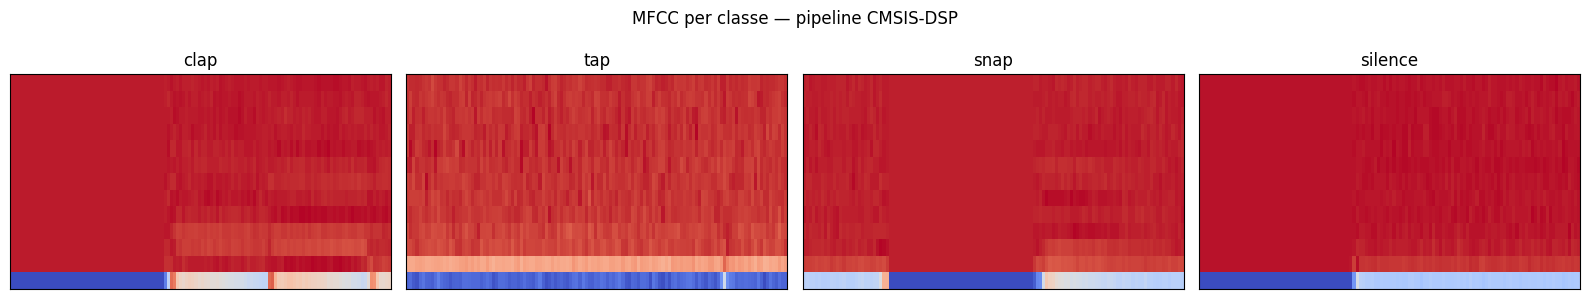

In [ ]:
import librosa          # solo per il caricamento audio
import librosa.display
import matplotlib.pyplot as plt
from scipy.fft import rfft
from scipy.signal import get_window

# ── Hamming window (identica a Arduino: 0.54 - 0.46*cos(2pi*i/(N-1))) ────────
_hamming = 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(FRAME_LEN) / (FRAME_LEN - 1))
_hamming = _hamming.astype(np.float32)

# ── Mel filterbank manuale — triangolare, NO norm Slaney ─────────────────────
def _build_mel_fb():
    def hz2mel(h): return 2595.0 * np.log10(1.0 + h / 700.0)
    def mel2hz(m): return 700.0 * (10.0 ** (m / 2595.0) - 1.0)

    mel_low  = hz2mel(MEL_LOW_HZ)
    mel_high = hz2mel(MEL_HIGH_HZ)
    mel_pts  = np.linspace(mel_low, mel_high, N_MEL + 2)
    # Bin index identico all'Arduino: int(floor((FRAME_LEN+1)*hz/SR))
    bin_idx  = np.floor((FRAME_LEN + 1) * mel2hz(mel_pts) / SAMPLE_RATE).astype(int)
    bin_idx  = np.clip(bin_idx, 0, N_FFT_BINS - 1)

    fb = np.zeros((N_MEL, N_FFT_BINS), dtype=np.float32)
    for m in range(N_MEL):
        lo, ctr, hi = bin_idx[m], bin_idx[m+1], bin_idx[m+2]
        if ctr != lo:
            for k in range(lo, ctr):
                fb[m, k] = (k - lo) / (ctr - lo)
        if hi != ctr:
            for k in range(ctr, hi + 1):
                fb[m, k] = (hi - k) / (hi - ctr)
    return fb

_mel_fb = _build_mel_fb()   # (26, 129)

# ── DCT-II senza normalizzazione ortonormale ──────────────────────────────────
# dct[k] = sum_m cos(pi*k*(2m+1)/(2*N_MEL)) * log_mel[m]  — identica all'Arduino
_m_idx = np.arange(N_MEL, dtype=np.float32)
_k_idx = np.arange(N_MFCC, dtype=np.float32)
_dct_mat = np.cos(np.pi * _k_idx[:, None] * (2 * _m_idx[None, :] + 1)
                  / (2 * N_MEL)).astype(np.float32)  # (13, 26)

# ── Pipeline MFCC principale ─────────────────────────────────────────────────
def extract_mfcc(path):
    """
    Replica esatta della pipeline CMSIS-DSP dello sketch Arduino:
      1. int16→float / 32768
      2. Pre-emphasis per-frame
      3. Hamming window
      4. RFFT N=256 (scipy, no norm)
      5. Power spectrum |X|²
      6. Mel filterbank triangolare, no Slaney
      7. ln(mel + 1e-9)
      8. DCT-II no ortho
    Ritorna: float32 array (N_MFCC=13, NUM_FRAMES=124)
    """
    # Caricamento: librosa restituisce float32 in [-1,1]
    y, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True, duration=CLIP_DURATION)
    # Pad/trim a esattamente N_SAMPLES
    if len(y) < N_SAMPLES:
        y = np.pad(y, (0, N_SAMPLES - len(y)))
    else:
        y = y[:N_SAMPLES]
    # librosa carica già in float32 [-1,1] (equiv. a int16/32768)
    y = y.astype(np.float32)

    mfcc_out = np.zeros((N_MFCC, NUM_FRAMES), dtype=np.float32)

    for f in range(NUM_FRAMES):
        frame = y[f * HOP_LEN : f * HOP_LEN + FRAME_LEN].copy()

        # 2. Pre-emphasis per-frame (identico Arduino: _sig[0]=_pcm[0])
        sig = np.empty(FRAME_LEN, dtype=np.float32)
        sig[0] = frame[0]
        sig[1:] = frame[1:] - PRE_EMPHASIS * frame[:-1]

        # 3. Hamming window
        windowed = sig * _hamming

        # 4. RFFT N=256 — scipy.fft.rfft, NO normalizzazione
        #    arm_rfft_fast_f32 produce lo stesso output non-normalizzato
        X = rfft(windowed, n=FRAME_LEN)   # complex128, shape (129,)

        # 5. Power spectrum |X[k]|²
        power = (X.real ** 2 + X.imag ** 2).astype(np.float32)  # (129,)

        # 6. Mel filterbank (dot product identico all'Arduino)
        mel_e = _mel_fb @ power            # (26,)

        # 7. Log naturale
        log_mel = np.log(mel_e + 1e-9)    # ln, non log10

        # 8. DCT-II senza normalizzazione
        mfcc_out[:, f] = _dct_mat @ log_mel

    return mfcc_out   # (13, 124)


# ── Verifica shape + visualizzazione ─────────────────────────────────────────
for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    wavs = [f for f in os.listdir(cls_dir) if f.endswith('.wav')]
    if wavs:
        sample_mfcc = extract_mfcc(os.path.join(cls_dir, wavs[0]))
        print(f'MFCC shape ({cls}): {sample_mfcc.shape}  ← atteso ({N_MFCC}, {NUM_FRAMES})')
        assert sample_mfcc.shape == (N_MFCC, NUM_FRAMES), 'Shape errata!'
        break

fig, axes = plt.subplots(1, len(CLASSES), figsize=(16, 3))
for ax, cls in zip(axes, CLASSES):
    cls_dir = os.path.join(DATA_ROOT, cls)
    wavs = [f for f in os.listdir(cls_dir) if f.endswith('.wav')]
    if wavs:
        m = extract_mfcc(os.path.join(cls_dir, wavs[0]))
        librosa.display.specshow(m, ax=ax, sr=SAMPLE_RATE, hop_length=HOP_LEN)
        ax.set_title(cls)
plt.suptitle('MFCC per classe — pipeline CMSIS-DSP')
plt.tight_layout(); plt.show()


In [ ]:
from tqdm import tqdm

X_list, y_list = [], []

for label_idx, cls in enumerate(CLASSES):
    cls_dir = os.path.join(DATA_ROOT, cls)
    wavs = [f for f in os.listdir(cls_dir) if f.lower().endswith('.wav')]
    print(f'Processo {cls} ({len(wavs)} file)...')
    ok = 0
    for wav in tqdm(wavs, leave=False):
        try:
            mfcc = extract_mfcc(os.path.join(cls_dir, wav))
            X_list.append(mfcc)
            y_list.append(label_idx)
            ok += 1
        except Exception as e:
            print(f'  Saltato {wav}: {e}')
    print(f'  → {ok} estratti ✅')

X = np.array(X_list)
y = np.array(y_list)
print(f'\nDataset finale: X={X.shape}, y={y.shape}')
for i, cls in enumerate(CLASSES):
    print(f'  [{i}] {cls}: {np.sum(y==i)} campioni')

Processo clap (260 file)...


  → 260 estratti ✅
Processo tap (260 file)...


  → 260 estratti ✅
Processo snap (260 file)...


  → 260 estratti ✅
Processo silence (260 file)...


  → 260 estratti ✅

Dataset finale: X=(1040, 13, 124), y=(1040,)
  [0] clap: 260 campioni
  [1] tap: 260 campioni
  [2] snap: 260 campioni
  [3] silence: 260 campioni


## 6 — Normalizzazione e split

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Normalizzazione per-coefficiente MFCC
# X shape: (N, 13, 124) → mean/std shape: (1, 13, 1)
X_mean = X.mean(axis=(0, 2), keepdims=True)    # shape (1, 13, 1)
X_std  = X.std(axis=(0, 2),  keepdims=True) + 1e-8

X_norm = (X - X_mean) / X_std
print(f'Normalizzazione per-coefficiente:')
print(f'  mean shape: {X_mean.shape}, range: [{X_mean.min():.2f}, {X_mean.max():.2f}]')
print(f'  std  shape: {X_std.shape},  range: [{X_std.min():.4f}, {X_std.max():.4f}]')

X_cnn = X_norm[..., np.newaxis]  # (N, 13, 124, 1)  ← input shape CNN
y_oh  = tf.keras.utils.to_categorical(y, num_classes=N_CLASSES)

min_count = min(np.sum(y == i) for i in range(N_CLASSES))
use_stratify = min_count >= 2

X_train, X_val, y_train, y_val = train_test_split(
    X_cnn, y_oh,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=(y if use_stratify else None)
)

print(f'Train: {X_train.shape}, Val: {X_val.shape}')
assert X_train.shape[1:] == (N_MFCC, NUM_FRAMES, 1), \
    f'Input shape CNN errata: {X_train.shape[1:]}'
if not use_stratify:
    print('⚠ Stratify disabilitato (alcune classi hanno < 2 campioni).')


Normalizzazione per-coefficiente:
  mean shape: (1, 13, 1), range: [-308.45, 0.01]
  std  shape: (1, 13, 1),  range: [2.1812, 160.9628]
Train: (832, 13, 124, 1), Val: (208, 13, 124, 1)


## 7 — CNN con Dropout e regolarizzazione avanzata

Architettura ottimizzata per dataset piccoli con augmentation on-the-fly.

In [ ]:
from tensorflow.keras import layers, models, callbacks, regularizers

def build_model(input_shape, n_classes):
    inp = layers.Input(shape=input_shape)

    # Blocco 1 — 16 filtri (era 32)
    x = layers.Conv2D(16, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)       # era 0.2

    # Blocco 2 — 32 filtri (era 64)
    x = layers.Conv2D(32, (3, 3), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)       # era 0.2

    # Blocco 3 rimosso — GlobalAvgPool direttamente
    # (era Conv2D(128) → overfitting con dataset piccolo)
    x = layers.GlobalAveragePooling2D()(x)

    # Testa — Dense 64 (era 128)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    return models.Model(inp, out, name='mfcc_cnn_light')


model = build_model(X_cnn.shape[1:], N_CLASSES)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "mfcc_cnn_light"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 13, 124, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 13, 124, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 124, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 13, 124, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 62, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 62, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 62, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 62, 32)      │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 6, 62, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 31, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 31, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,364 (28.77 KB)

 Trainable params: 7,268 (28.39 KB)

 Non-trainable params: 96 (384.00 B)

## 8 — Training con augmentation on-the-fly

In [ ]:
# Augmentation on-the-fly sul tensor (jitter su MFCC)
def mfcc_augment(x, y):
    # Aggiungi rumore gaussiano sulle feature MFCC
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.05)
    x = x + noise
    # SpecAugment leggero: maschera casuale su righe (frequenze)
    mask_size = tf.random.uniform([], 1, 3, dtype=tf.int32)
    mask_start = tf.random.uniform([], 0, N_MFCC - mask_size, dtype=tf.int32)
    mask = tf.ones([mask_start, NUM_FRAMES, 1])
    mask = tf.concat([mask,
                      tf.zeros([mask_size, NUM_FRAMES, 1]),
                      tf.ones([N_MFCC - mask_start - mask_size, NUM_FRAMES, 1])], axis=0)
    x = x * mask
    return x, y

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset
            .from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .map(mfcc_augment, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds = (tf.data.Dataset
          .from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

cb_list = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10,   # ↓ era 15
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-5, verbose=1)  # ↓ era 7
]

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=cb_list,
    verbose=1
)


Epoch 1/60
52/52 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.3462 - loss: 1.3980 - val_accuracy: 0.3510 - val_loss: 1.3378 - learning_rate: 0.0010
Epoch 2/60
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4820 - loss: 1.1653 - val_accuracy: 0.5240 - val_loss: 1.1784 - learning_rate: 0.0010
Epoch 3/60
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5829 - loss: 1.0340 - val_accuracy: 0.6298 - val_loss: 1.0051 - learning_rate: 0.0010
Epoch 4/60
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5925 - loss: 0.9935 - val_accuracy: 0.5529 - val_loss: 0.9668 - learning_rate: 0.0010
Epoch 5/60
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6575 - loss: 0.8925 - val_accuracy: 0.6298 - val_loss: 0.8354 - learning_rate: 0.0010
Epoch 6/60
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6659 - loss: 0.8508 - val_accuracy: 0.6394 - val_loss: 0.8167 - learning_rate: 0.0010
Epoch 7/60
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6370 - loss: 0.8628 - val_accuracy:

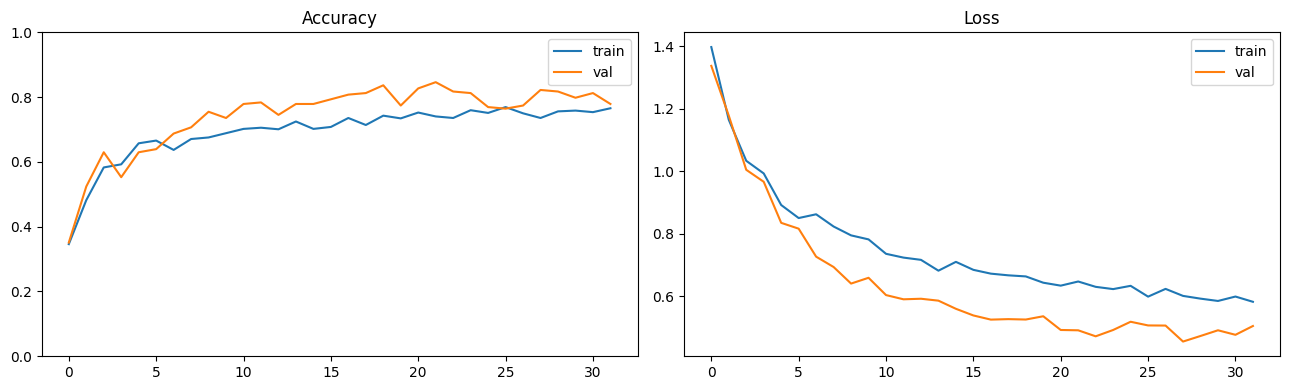


Val accuracy: 84.6%  |  Val loss: 0.4915


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['accuracy'],     label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].set_ylim(0, 1); axes[0].legend()
axes[1].plot(history.history['loss'],     label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f'\nVal accuracy: {val_acc*100:.1f}%  |  Val loss: {val_loss:.4f}')

## 9 — Valutazione & Confusion Matrix

              precision    recall  f1-score   support

        clap       1.00      0.63      0.78        52
         tap       0.79      0.96      0.87        52
        snap       0.84      0.88      0.86        52
     silence       0.82      0.90      0.86        52

    accuracy                           0.85       208
   macro avg       0.86      0.85      0.84       208
weighted avg       0.86      0.85      0.84       208



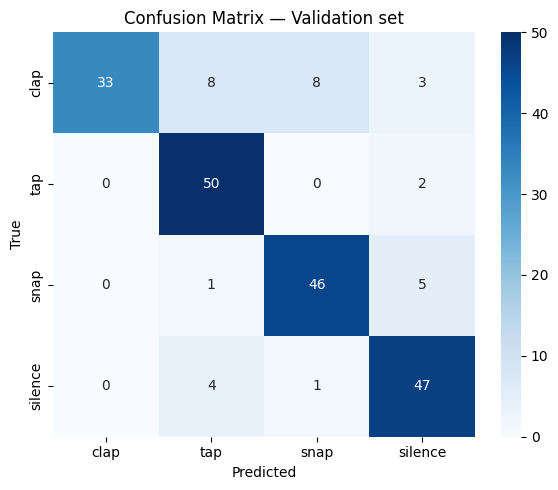

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true     = np.argmax(y_val, axis=1)
y_pred_cls = np.argmax(model.predict(X_val, verbose=0), axis=1)

print(classification_report(y_true, y_pred_cls, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred_cls)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix — Validation set')
plt.tight_layout(); plt.show()

## 10 — Export TFLite INT8

In [ ]:
def representative_dataset():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

TFLITE_PATH = 'keyword_model.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)
print(f'TFLite salvato → {TFLITE_PATH}  ({os.path.getsize(TFLITE_PATH)/1024:.1f} KB)')

# Parametri quantizzazione
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
in_det  = interpreter.get_input_details()[0]
out_det = interpreter.get_output_details()[0]
in_scale,  in_zp  = in_det['quantization']
out_scale, out_zp = out_det['quantization']
print(f'Input  scale={in_scale:.6f}, zero_point={in_zp}')
print(f'Output scale={out_scale:.6f}, zero_point={out_zp}')

Saved artifact at '/tmp/tmp40quo19c'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13, 124, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138055600602192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138055600602576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138055295845584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138055600599696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138055295846544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138055295844816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138055295846736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138055295845200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138055295845392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138055295847696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138055295847504

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TFLite salvato → keyword_model.tflite  (14.4 KB)
Input  scale=0.050525, zero_point=-5
Output scale=0.003906, zero_point=-128


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### 10b — Verifica accuratezza TFLite INT8

In [ ]:
correct = 0
for i in range(len(X_val)):
    inp_q = np.round(X_val[i:i+1] / in_scale + in_zp).clip(-128,127).astype(np.int8)
    interpreter.set_tensor(in_det['index'], inp_q)
    interpreter.invoke()
    out_q = interpreter.get_tensor(out_det['index'])
    pred  = np.argmax((out_q.astype(np.float32) - out_zp) * out_scale)
    if pred == y_true[i]: correct += 1

print(f'TFLite INT8 val accuracy: {correct}/{len(X_val)} = {100*correct/len(X_val):.1f}%')

TFLite INT8 val accuracy: 176/208 = 84.6%


## 11 — Generazione `model.h` con `xxd`

Metodo esatto delle slide di deployment:
```python
!echo "const unsigned char model[] = {" > model.h
!cat keyword_model.tflite | xxd -i          >> model.h
!echo "};"                                  >> model.h
```
Il file va copiato nella **stessa cartella** dello sketch Arduino.

In [ ]:
# Step 1 — corpo xxd (come da slide)
!echo "const unsigned char model[] = {" > model.h
!cat keyword_model.tflite | xxd -i          >> model.h
!echo "};"                                  >> model.h

# Step 2 — prepend header con tutti i #define
with open('model.h', 'r') as f:
    xxd_body = f.read()

# Appiattisci mean e std: shape (1,13,1) → (13,) — un valore per coefficiente
mean_flat = X_mean.flatten().astype('float32')
std_flat  = X_std.flatten().astype('float32')
mean_str  = ', '.join(f'{v:.8f}f' for v in mean_flat)
std_str   = ', '.join(f'{v:.8f}f' for v in std_flat)
classes_str = ', '.join(f'"{c}"' for c in CLASSES)

header = f"""// model.h — generato da MFCC_Arduino_Training.ipynb
// Copiare nella stessa cartella dello sketch Arduino.
#pragma once
#include <stdint.h>

// ── Parametri MFCC (identici all'Arduino sketch) ──────────────────────────────
#define SAMPLE_RATE        {SAMPLE_RATE}
#define FRAME_LEN          {FRAME_LEN}
#define HOP_LEN            {HOP_LEN}
#define N_MEL              {N_MEL}
#define N_MFCC             {N_MFCC}
#define MEL_LOW_HZ         {MEL_LOW_HZ:.1f}f
#define MEL_HIGH_HZ        {MEL_HIGH_HZ:.1f}f
#define PRE_EMPHASIS       {PRE_EMPHASIS:.2f}f
#define CLIP_SAMPLES       {N_SAMPLES}

// ── Normalizzazione per-coefficiente (array di N_MFCC=13 valori) ──────────────
// Usare: norm = (mfcc[c][t] - NORM_MEAN[c]) / NORM_STD[c]
static const float NORM_MEAN[N_MFCC] = {{ {mean_str} }};
static const float NORM_STD [N_MFCC] = {{ {std_str}  }};

// ── Quantizzazione TFLite INT8 ────────────────────────────────────────────────
#define INPUT_SCALE        {in_scale:.8f}f
#define INPUT_ZERO_POINT   {in_zp}
#define OUTPUT_SCALE       {out_scale:.8f}f
#define OUTPUT_ZERO_POINT  {out_zp}

// ── Etichette classi ──────────────────────────────────────────────────────────
#define N_CLASSES          {N_CLASSES}
static const char* const CLASS_LABELS[] = {{ {classes_str} }};

// ── Modello TFLite (xxd) ──────────────────────────────────────────────────────
"""

with open('model.h', 'w') as f:
    f.write(header + xxd_body)

print(f'model.h pronto: {os.path.getsize("model.h")/1024:.1f} KB')
!head -35 model.h


model.h pronto: 90.7 KB
// model.h — generato da MFCC_Arduino_Training.ipynb
// Copiare nella stessa cartella dello sketch Arduino.
#pragma once
#include <stdint.h>

// ── Parametri MFCC (identici all'Arduino sketch) ──────────────────────────────
#define SAMPLE_RATE        16000
#define FRAME_LEN          256
#define HOP_LEN            128
#define N_MEL              26
#define N_MFCC             13
#define MEL_LOW_HZ         300.0f
#define MEL_HIGH_HZ        8000.0f
#define PRE_EMPHASIS       0.97f
#define CLIP_SAMPLES       16000

// ── Normalizzazione per-coefficiente (array di N_MFCC=13 valori) ──────────────
// Usare: norm = (mfcc[c][t] - NORM_MEAN[c]) / NORM_STD[c]
static const float NORM_MEAN[N_MFCC] = { -308.45465088f, -21.36962700f, -4.67381477f, -2.87489104f, -0.44097009f, -0.93039739f, -1.00346208f, -0.15061364f, -0.11517536f, -0.02718289f, -0.31541961f, -0.31405061f, 0.00903313f };
static const float NORM_STD [N_MFCC] = { 160.96282959f, 17.22010612f, 6.79569340f, 4.97240448

## 12 — Download

In [ ]:
from google.colab import files as colab_files
colab_files.download('keyword_model.tflite')
colab_files.download('model.h')
print('Download avviati — model.h va nella cartella dello sketch Arduino.')

## 13 — Smoke-test su singolo file audio

In [ ]:
from google.colab import files
uploaded_test = files.upload()   # carica un .wav o .mp4
test_path = list(uploaded_test.keys())[0]

# Converti se mp4
if test_path.lower().endswith('.mp4'):
    audio = AudioSegment.from_file(test_path, format='mp4')
    audio = audio.set_channels(1).set_frame_rate(SAMPLE_RATE)
    test_path_wav = test_path.replace('.mp4', '_test.wav')
    audio.export(test_path_wav, format='wav')
    test_path = test_path_wav

# Pipeline CMSIS-identica
mfcc_test = extract_mfcc(test_path)                   # (13, 124)
# Normalizzazione per-coefficiente
mfcc_norm = (mfcc_test - X_mean[0, :, 0:1]) / X_std[0, :, 0:1]   # broadcast (13,1)
mfcc_inp  = mfcc_norm[np.newaxis, ..., np.newaxis].astype(np.float32)  # (1,13,124,1)
mfcc_q    = np.round(mfcc_inp / in_scale + in_zp).clip(-128, 127).astype(np.int8)

interpreter.set_tensor(in_det['index'], mfcc_q)
interpreter.invoke()
out_q = interpreter.get_tensor(out_det['index'])[0]
probs = (out_q.astype(np.float32) - out_zp) * out_scale

pred_class = CLASSES[np.argmax(probs)]
print(f'\n→ Classe predetta: {pred_class.upper()}')
for cls, p in zip(CLASSES, probs):
    bar = '█' * int(max(p, 0) * 30)
    print(f'  {cls:8s}: {p:.4f}  {bar}')


Saving tap4.wav to tap4.wav

→ Classe predetta: TAP
  clap    : 0.0039  
  tap     : 0.9961  █████████████████████████████
  snap    : 0.0000  
  silence : 0.0000  


---
## Riepilogo

| File | Destinazione |
|---|---|
| `keyword_model.tflite` | Riferimento / TFLite Micro |
| `model.h` | Cartella sketch Arduino |

### Snippet Arduino
```cpp
#include "model.h"

// 1. Pre-emphasis
for (int i = n - 1; i > 0; i--)
    frame[i] -= PRE_EMPHASIS * frame[i - 1];

// 2. Normalizzazione per-coefficiente
//    mfcc_buf[coeff][frame] — itera su ogni coefficiente MFCC
for (int c = 0; c < N_MFCC; c++) {
    for (int t = 0; t < N_FRAMES; t++) {
        mfcc_buf[c][t] = (mfcc_buf[c][t] - NORM_MEAN[c]) / NORM_STD[c];
    }
}

// 3. Quantizzazione input (per ogni elemento del tensore)
int8_t q = (int8_t)roundf(norm_val / INPUT_SCALE + INPUT_ZERO_POINT);

// 4. De-quantizzazione output
float prob = (output[i] - OUTPUT_ZERO_POINT) * OUTPUT_SCALE;

// 5. Stampa risultato
Serial.println(CLASS_LABELS[argmax(output)]);
```
